**Clustering**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
milk = pd.read_csv('../datasets/milk.csv',index_col=0)
milk

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,90.1,2.6,1.0,6.9,0.35
ORANGUTAN,88.5,1.4,3.5,6.0,0.24
MONKEY,88.4,2.2,2.7,6.4,0.18
DONKEY,90.3,1.7,1.4,6.2,0.40
HIPPO,90.4,0.6,4.5,4.4,0.10
CAMEL,87.7,3.5,3.4,4.8,0.71
BISON,86.9,4.8,1.7,5.7,0.90
BUFFALO,82.1,5.9,7.9,4.7,0.78
GUINEA PIG,81.9,7.4,7.2,2.7,0.85


In [4]:
scaler = StandardScaler().set_output(transform='pandas')
milk_scaled = scaler.fit_transform(milk)

#Scaled values
milk_scaled

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,0.948806,-1.009291,-0.903208,1.542217,-1.037554
ORANGUTAN,0.821407,-1.344603,-0.660619,1.040773,-1.259945
MONKEY,0.813445,-1.121062,-0.738247,1.263637,-1.381249
DONKEY,0.964731,-1.260775,-0.864394,1.152205,-0.936467
HIPPO,0.972694,-1.568145,-0.563583,0.149319,-1.542988
CAMEL,0.757707,-0.757806,-0.670322,0.372182,-0.309730
BISON,0.694008,-0.394551,-0.835283,0.873626,0.074400
BUFFALO,0.311810,-0.087181,-0.233662,0.316466,-0.168208
GUINEA PIG,0.295885,0.331959,-0.301587,-0.797852,-0.026687


In [5]:
from sklearn.cluster import KMeans


km = KMeans(n_clusters = 4, random_state = 25)
km.fit(milk_scaled)
silhouette_score(milk_scaled, km.labels_)

0.42324551444775393

In [9]:
clusters = np.arange(2,9)
scores = []
for i in clusters:
    km = KMeans(n_clusters = i, random_state = 25)
    km.fit(milk_scaled)
    scores.append([i, silhouette_score(milk_scaled, km.labels_)])

scores_df = pd.DataFrame(columns=['clusters', 'score'], data = scores)
scores_df.sort_values('score', ascending=False)


,clusters,score
0,2,0.525851
2,4,0.423246
4,6,0.412161
3,5,0.399843
5,7,0.398780
6,8,0.397209
1,3,0.353503


PCA Plot

c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


InvalidIndexError: (slice(None, None, None), 0)

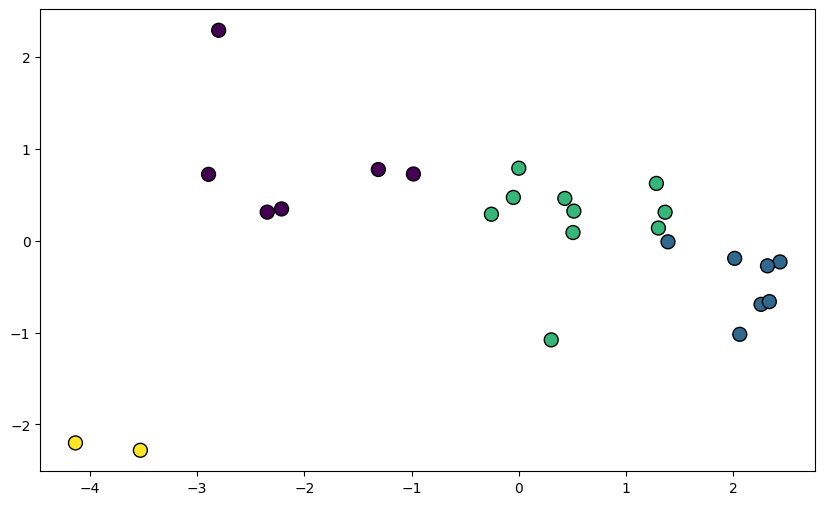

In [10]:
# PCA Plot
pca = PCA(n_components=2).set_output(transform='pandas')
milk_pca = pca.fit_transform(milk_scaled)

# Train KMeans with optimal clusters (from previous results)
km = KMeans(n_clusters=4, random_state=25)
km.fit(milk_scaled)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(milk_pca.iloc[:, 0], milk_pca.iloc[:, 1], c=km.labels_, cmap='viridis', s=100, edgecolors='black')
plt.scatter(pca.transform(km.cluster_centers_)[:, 0], pca.transform(km.cluster_centers_)[:, 1], 
            c='red', marker='X', s=300, edgecolors='black', label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering (PCA Visualization)')
plt.legend()
plt.colorbar(label='Cluster')
plt.show()